Data Augmentation using Augmentor

In [ ]:
%pip install Augmentor

In [2]:
import Augmentor

In [ ]:
augmentor=Augmentor.Pipeline(source_directory="sample_images",output_directory="augmented_images",save_format="png")

In [ ]:
# augmentation params
augmentor.flip_left_right(0.6)
augmentor.black_and_white(0.1)
augmentor.rotate(0.14,5,5)
augmentor.skew(0.7,magnitude=0.5)
augmentor.zoom(probability=0.3,min_factor=1.3,max_factor=1.7)
augmentor.sample(10)

Augmentation with Albumentations

In [ ]:
%pip install albumentations

In [ ]:
import albumentations as A
import cv2

In [24]:
# declaring an augmentation pipeline
augmentor=A.Compose([A.RandomCrop(256,256),
                     A.HorizontalFlip(p=0.5),
                     A.Rotate(limit=20, p=0.5),
                     A.RandomBrightnessContrast(p=0.5),
                     A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=1.0),
                     A.GaussNoise(std_range=(0.1, 0.2), p=1.0)])

In [25]:
# reading the mona lisa img with cv2
image=cv2.imread("sample_images//mona_lisa.jpg")
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

In [26]:
augmented=augmentor(image=image)
augmented_image=augmented["image"]


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

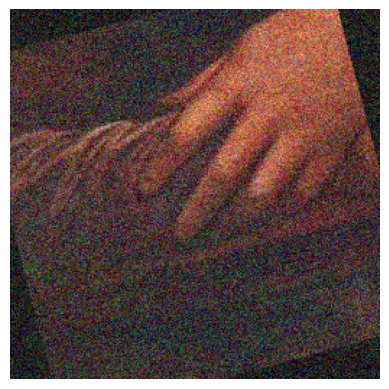

In [27]:
import matplotlib.pyplot as plt
plt.subplot(111)
plt.imshow(augmented_image)
plt.axis("off")

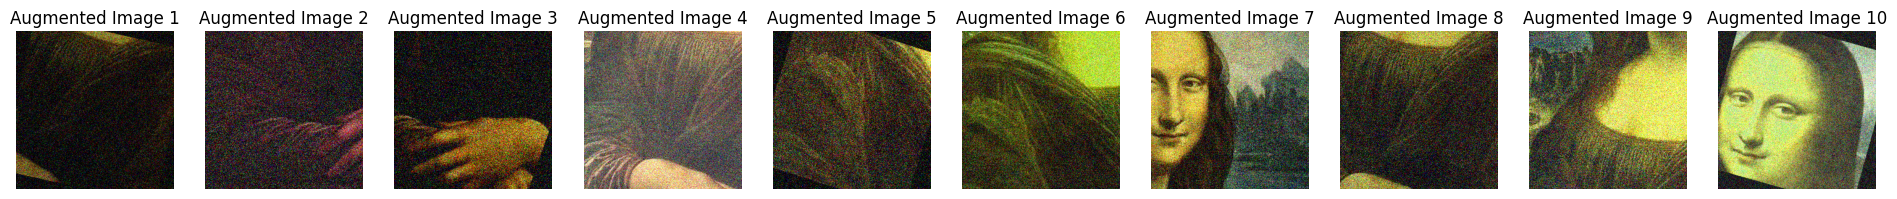

In [31]:
plt.figure(figsize=(24,24))
for i in range (10):
    augmented=augmentor(image=image)
    augmented_image=augmented["image"]
    plt.subplot(1,10,i+1)
    plt.imshow(augmented_image)
    plt.title(f"Augmented Image {i+1}")
    plt.axis("off")
plt.show()


In [36]:
def visualize(image):
    plt.imshow(image)
    plt.axis("off")
    plt.show()

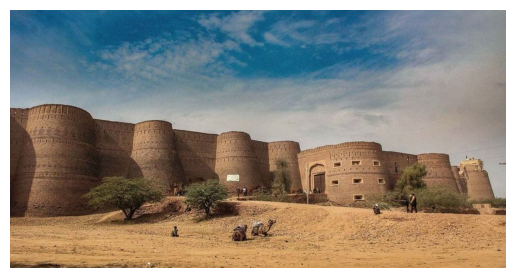

In [38]:
import numpy as np
from PIL import Image
fort_image=Image.open("sample_images//derawar_fort.jpg")
visualize(fort_image)

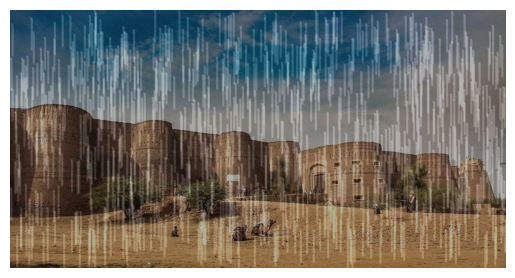

In [44]:
# converting the img to a numpy array
fort_np=np.array(fort_image)
transform=A.RandomRain(brightness_coefficient=0.7,
                       drop_width=1,
                       blur_value=4,
                       p=0.7,
                       rain_type="torrential")
transformed=transform(image=fort_np)
visualize(transformed["image"])

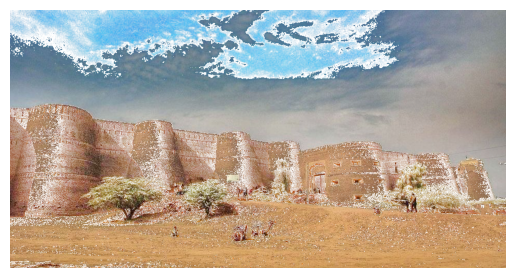

In [47]:
transform=A.RandomSnow(brightness_coeff=2.5,
                        p=1,
                        method="bleach")
transformed=transform(image=fort_np)
visualize(transformed["image"])

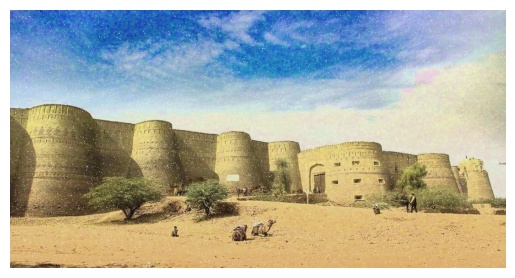

In [48]:
transform=A.RandomSnow(brightness_coeff=2.5,
                        p=1,
                        method="texture")
transformed=transform(image=fort_np)
visualize(transformed["image"])